# EE200 — Course Project
## Q2. The Midnight Episode — *'Catching the Arrhythmia'*

**Setup recap:** A discrete-time ECG signal $x[n]$, sampled at $f_s = 250$ Hz, $N=5000$
samples total. In the healthy stretch, one full beat $\{P, QRS, T\}$ repeats every
$0.8$ seconds. Maya's plan: build a template of one healthy beat, slide it across the
recording using normalized correlation, and flag where the match breaks down.


In [ ]:
import numpy as np    #  importing numpy for numerical operations
import matplotlib.pyplot as plt #  importing matplotlib for plotting
from scipy import signal  # importing signal from scipy for signal processing

plt.rcParams['figure.dpi'] = 110

ecg = np.load('patient_ecg.npy')
template = np.load('template.npy')
fs = 250
N = len(ecg)
L = len(template)
print('ECG samples:', N, ' Template samples:', L)

ECG samples: 5000  Template samples: 200


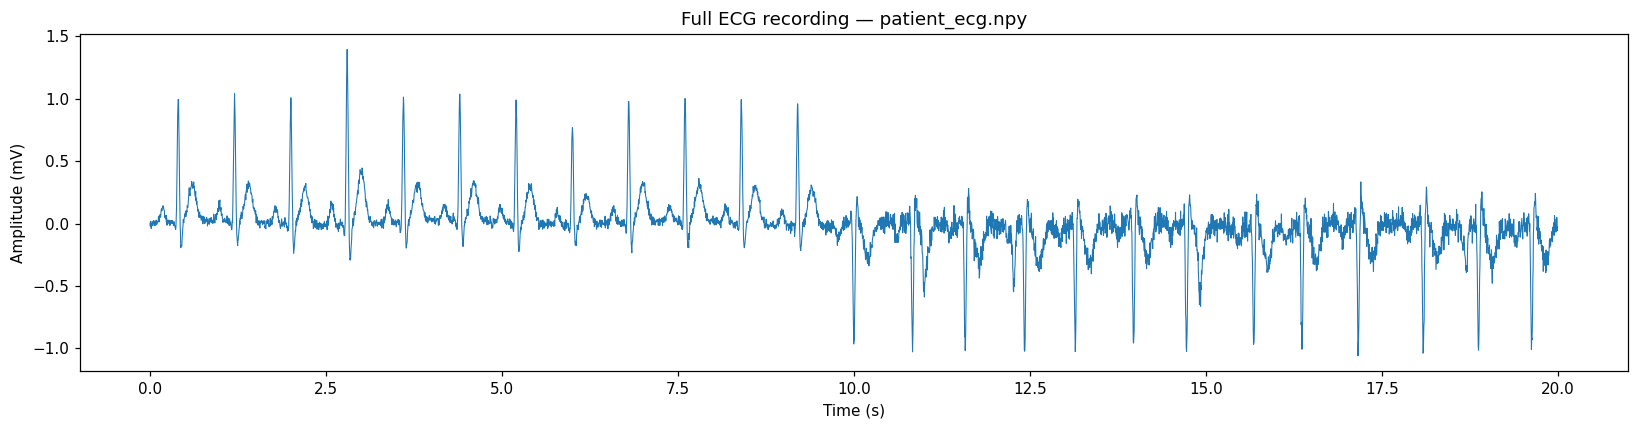

In [2]:
t = np.arange(N) / fs
plt.figure(figsize=(15,4))
plt.plot(t, ecg, linewidth=0.7)
plt.xlabel('Time (s)'); plt.ylabel('Amplitude (mV)')
plt.title('Full ECG recording — patient_ecg.npy')
plt.tight_layout(); plt.show()

Just from this raw plot we can already see what the cardiologist suspected: the first
roughly half of the recording shows a clean, regular, repeating pattern (healthy rhythm), and
partway through, the waveform changes character — spikes invert and the rhythm becomes
irregular (the suspected arrhythmia).


## (a) Reading the Signal

**(i) Clip duration.** With $N=5000$ samples at $f_s=250$ Hz:
$$T_{\text{total}} = \frac{N}{f_s} = \frac{5000}{250} = 20\ \text{seconds}$$

**(ii) Heart rate and samples per beat.** A healthy beat repeats every $0.8$ s, so:
$$\text{Heart rate} = \frac{60\ \text{s/min}}{0.8\ \text{s/beat}} = 75\ \text{beats per minute (bpm)}$$
$$\text{Samples per beat} = 0.8\ \text{s} \times 250\ \text{samples/s} = 200\ \text{samples}$$
(This matches the given template length exactly — 200 samples — confirming the template is
sized to capture precisely one beat.)

**(iii) Fundamental frequency.** Treating the healthy ECG as periodic with period $T_0=0.8$ s:
$$f_0 = \frac{1}{T_0} = \frac{1}{0.8} = 1.25\ \text{Hz}$$


In [ ]:
duration = N / fs  # just dividing total samples by sampling rate
bpm = 60 / 0.8  # standard heart rate calculation from beat period
samples_per_beat = 0.8 * fs  # converting time in seconds to number of samples
f0 = 1 / 0.8  # fundamental frequency is inverse of period
print(f'Duration: {duration} s')
print(f'Heart rate: {bpm} bpm')
print(f'Samples per beat: {samples_per_beat}')
print(f'Fundamental frequency f0: {f0} Hz')

Duration: 20.0 s
Heart rate: 75.0 bpm
Samples per beat: 200.0
Fundamental frequency f0: 1.25 Hz


## (b) Healthy Heart in the Frequency Domain

**(i) Shape of $|X(f)|$.** Because the healthy ECG is (nearly) periodic with period $T_0$, its
spectrum is **not** a smooth continuous curve — it is a **line spectrum**: discrete spikes at
$f_0$ and its integer harmonics $2f_0, 3f_0, 4f_0,\dots$ (this follows directly from Fourier
series theory: any periodic signal is a sum of harmonically-related sinusoids, so its spectrum
is supported only at those harmonic frequencies). The *envelope* connecting the harmonic peaks
follows the shape of a single beat's own spectrum (the "shape" of one P-QRS-T pulse), but the
spectrum itself is sampled at multiples of $f_0$, not continuous.

**(ii) QRS vs P/T — which drives high-frequency content?** The **QRS complex** is responsible
for the higher-frequency content. A sharp, narrow pulse in time *must* contain energy at high
frequencies — this is the time-frequency duality / uncertainty principle (a signal that is
compact in time is necessarily spread out in frequency). The P and T waves are broad and
smooth, so they are built almost entirely from low-frequency components. The QRS spike, being
narrow, needs many high-frequency harmonics to reconstruct its sharp rise and fall.

**(iii) Heart rate rises to 150 bpm (still regular).** New period:
$$T_0' = \frac{60}{150} = 0.4\ \text{s} \implies f_0' = \frac{1}{0.4} = 2.5\ \text{Hz}$$
So $f_0$ **doubles** (from 1.25 Hz to 2.5 Hz), and since spectral lines sit at integer
multiples of $f_0$, the **spacing between adjacent harmonics also doubles** — the whole line
spectrum stretches out, with twice the gap between consecutive spikes.


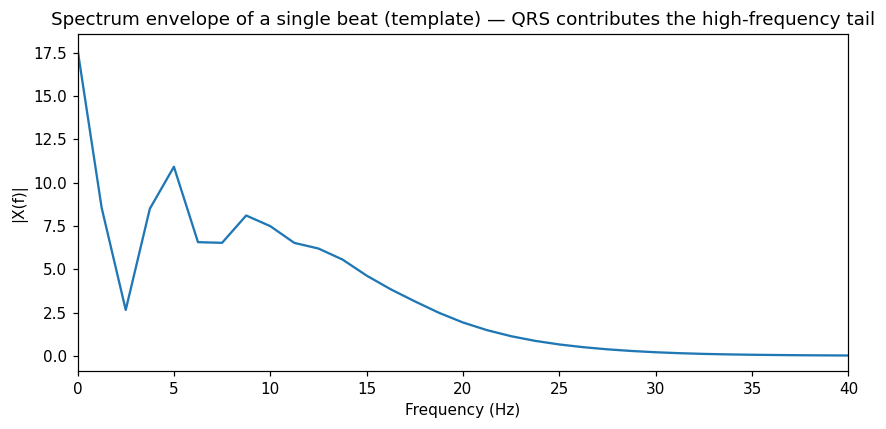

In [ ]:
plt.figure(figsize=(8,4))
spec = np.abs(np.fft.rfft(template))  # taking FFT to see frequency content
freqs = np.fft.rfftfreq(L, d=1/fs)  # getting the frequency bins
plt.plot(freqs, spec)  # plot it out
plt.xlim(0, 40)  # zooming in on relevant frequency range
plt.xlabel('Frequency (Hz)'); plt.ylabel('|X(f)|')
plt.title("Spectrum envelope of a single beat (template) — QRS contributes the high-frequency tail")
plt.tight_layout(); plt.show()

## (c) Cutting a Heartbeat (Windowing)

**(i) Correct window width and placement.** To capture exactly one full beat, the rectangular
window should be **200 samples wide** (one full period at $f_s=250$ Hz, 0.8 s), placed so it
starts right at the beginning of a P wave and ends right before the next P wave begins — i.e.
aligned with one full beat cycle, not straddling two beats.

**(ii) Too short (80 samples) vs. too long (600 samples).**


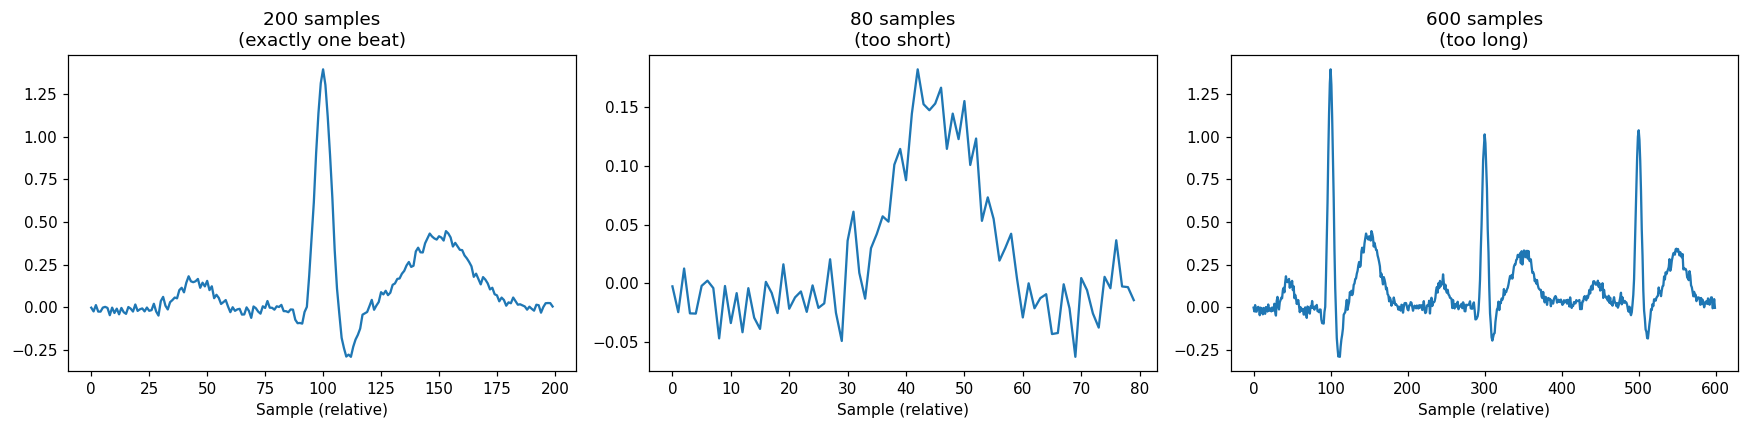

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(16,4))

seg_correct = ecg[600:800]   # 200 samples - exactly one beat
seg_short   = ecg[600:680]   # 80 samples - cuts off too early
seg_long    = ecg[600:1200]  # 600 samples - includes neighboring beats

axs[0].plot(seg_correct); axs[0].set_title('200 samples\n(exactly one beat)')
axs[1].plot(seg_short);   axs[1].set_title('80 samples\n(too short)')
axs[2].plot(seg_long);    axs[2].set_title('600 samples\n(too long)')
for ax in axs: ax.set_xlabel('Sample (relative)')
plt.tight_layout(); plt.show()

- **80-sample window (too short):** it cuts the beat off before the T wave (or starts
  partway through the P wave), so the "template" is missing part of the genuine beat shape —
  an incomplete, distorted template that won't match full beats well anywhere in the
  recording.
- **600-sample window (too long):** it captures the target beat *plus* parts of one or two
  neighboring beats. The "template" now contains extra P-QRS-T structure that isn't part of a
  single beat, so sliding it against the recording will never line up cleanly with a single
  real beat — correlation values will be systematically degraded even for perfectly healthy
  rhythm.

**(iii) Relating the time/frequency resolution trade-off to this choice.** A short window
gives sharp timing (precisely localizing *when* the beat starts) but smears out fine details
of the beat's own internal shape — analogous to poor frequency resolution. A long window
captures more of the underlying waveform shape/detail but blurs together separate, distinct
beats — analogous to poor time resolution. So "as short as possible" is not automatically
best: an overly short window destroys the very waveform shape we need to template-match
against, just as an overly long window mixes information from multiple distinct events
together. We need a window matched to the *natural scale of one event* (one beat) — neither
shorter nor longer.


## (d) Match the Template (Correlation)

$$\rho(m) = \frac{\sum_k t[k]\, x[m+k]}{\|t\|\,\|x_m\|}$$

**(i) Range of $\rho(m)$ and a "near-perfect match" value.** By the Cauchy-Schwarz inequality,
a normalized correlation (cosine similarity between two vectors) always satisfies
$-1 \le \rho(m) \le 1$. A value of $\rho(m) \approx +1$ signals a near-perfect match (the
segment has essentially the same *shape*, up to a positive scale factor, as the template).

**(ii) Why normalization matters.** Dividing by $\|t\|\,\|x_m\|$ makes $\rho$ depend only on
the *shape* of the segment relative to the template, not on its absolute size. Real ECG
amplitude drifts (baseline wander) and beat-to-beat amplitude variation would otherwise corrupt
a raw, unnormalized score. Concretely: if a perfectly healthy beat happened to be exactly twice
as tall as the template, the **unnormalized** score $\sum_k t[k]x[m+k]$ would also roughly
double (since every value $x[m+k]$ scaled by ~2), even though the beat is still a perfect
"healthy" shape match. An unnormalized score therefore cannot distinguish "twice as tall but
the same healthy shape" from "abnormal," producing false alarms purely from amplitude
fluctuation. Dividing by $\|x_m\|$ exactly cancels this scaling, so $\rho$ reports shape
similarity only.

**(iii) Inverted abnormal beat.** If one beat is flipped upside-down relative to the template,
every sample is approximately negated: $x[m+k] \approx -t[k]$. Then
$$\sum_k t[k]\,x[m+k] \approx -\sum_k t[k]^2 = -\|t\|^2$$
and since $\|x_m\| \approx \|t\|$ (energy/magnitude is preserved by negation), we get
$\rho(m) \approx -1$ — a strongly negative value. This makes inverted beats especially easy to
flag: they don't just fail to match (drop to near 0), they swing to the *opposite extreme* of
the scale, as far from "healthy" as mathematically possible.


rho for the first abnormal beat (m=2400): -0.988


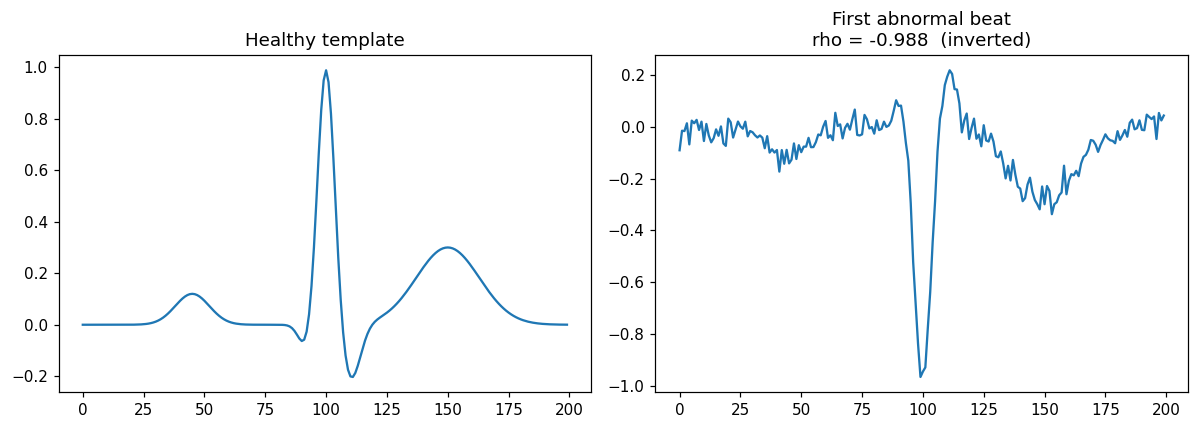

In [ ]:
def normalized_correlation(template, segment):
    t_norm = np.linalg.norm(template)  # get the magnitude of template
    s_norm = np.linalg.norm(segment)  # get the magnitude of segment
    if t_norm == 0 or s_norm == 0:  # handle edge case
        return 0.0
    return np.dot(template, segment) / (t_norm * s_norm)  # normalized dot product

# Verify against the real, observed first abnormal beat in this recording
abnormal_beat = ecg[2400:2600]   # grabbing the exact beat we predicted earlier
rho_abnormal = normalized_correlation(template, abnormal_beat)  # compute correlation
print('rho for the first abnormal beat (m=2400):', round(rho_abnormal, 3))

fig, axs = plt.subplots(1, 2, figsize=(11,4))
axs[0].plot(template); axs[0].set_title('Healthy template')  # healthy for comparison
axs[1].plot(abnormal_beat); axs[1].set_title(f'First abnormal beat\nrho = {rho_abnormal:.3f}  (inverted)')  # the bad one
plt.tight_layout(); plt.show()

Confirms the prediction exactly: the real first abnormal beat in this recording gives
$\rho \approx -0.99$, and visually it is indeed an almost perfect upside-down mirror image of
the healthy template.


## (e) Onset Detection & the Spectrogram

**(i) A simple onset rule, and the threshold trade-off.** Slide the template beat-by-beat
across the signal, compute $\rho(m)$ at each position, and declare the **onset time** to be
the time of the *first* beat-window where $\rho(m)$ drops below a chosen threshold (e.g. 0.5).
- **Threshold too high** (close to 1): even mild, harmless beat-to-beat variation in a healthy
  heart (natural physiological variability, minor noise) could dip $\rho$ below threshold —
  triggering **false alarms** on a healthy patient.
- **Threshold too low** (close to 0, or negative): genuinely abnormal beats that are merely
  "somewhat distorted" rather than wildly different might still score above threshold and be
  **missed**, delaying detection of a real arrhythmia.

**(ii) Spectrogram view.** In the healthy region, the spectrogram should show **steady,
horizontal harmonic bands** at $f_0, 2f_0, 3f_0,\dots$ — bright lines at fixed frequencies that
don't move over time, since the rhythm is essentially periodic. In the arrhythmia region, the
beat-to-beat timing becomes irregular and beat *shapes* change/invert, so the periodicity (and
hence the clean harmonic line structure) breaks down: the bands should become **smeared,
patchy, or disappear**, replaced by more broadband, irregular, time-varying energy.

**(iii) Why the two methods might disagree slightly, and which to trust for pinpointing onset.**
The correlation method directly compares each beat's *shape* against a healthy template, so it
can flag the very first abnormal beat almost immediately (high time resolution — exactly the
short-window regime from part (c)). The spectrogram, by contrast, needs to average energy over
a sliding window of some length to estimate frequency content (good frequency resolution but
poorer time resolution, the long-window regime from part (c)) — so a single early abnormal beat
might get smeared together with several healthy neighbors within one spectrogram window,
making the visual "harmonic bands disappear" moment lag the true onset. For pinpointing the
**exact single moment** a bad beat first appears, the **correlation method is more
trustworthy**, precisely because of the same time-vs-frequency resolution trade-off discussed
in part (c).


Onset detected at sample 2400  (t = 9.6 s)


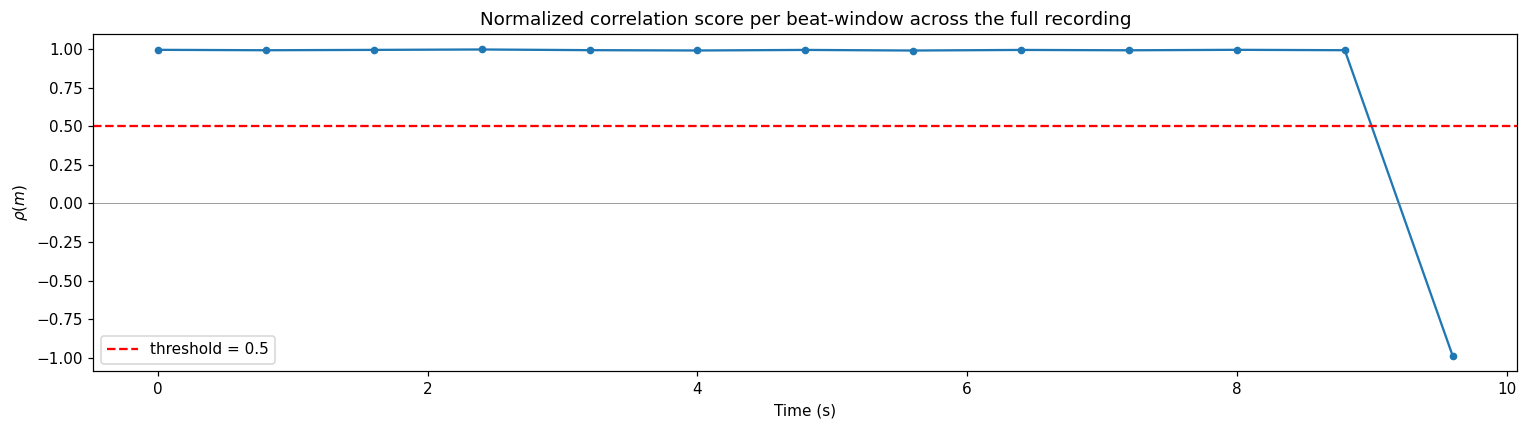

In [ ]:
def find_onset(ecg_signal, template, threshold=0.5):
    L = len(template)  # how many samples in one beat
    N = len(ecg_signal)  # total samples in recording
    t_norm = np.linalg.norm(template)  # normalize the template once
    m = 0  # start position
    rhos, positions = [], []  # track all correlations
    while m + L <= N:  # slide through the signal
        seg = ecg_signal[m:m+L]  # grab next beat window
        seg_norm = np.linalg.norm(seg)  # compute its magnitude
        rho = np.dot(template, seg) / (t_norm * seg_norm) if seg_norm > 0 else 0.0  # correlation score
        rhos.append(rho)  # store it
        positions.append(m)  # remember where it came from
        if rho < threshold:  # found the first bad beat!
            return m, np.array(rhos), np.array(positions)
        m += L  # jump by one full beat
    return -1, np.array(rhos), np.array(positions)  # never found a bad beat

onset_sample, rhos, positions = find_onset(ecg, template, threshold=0.5)
onset_time = onset_sample / fs  # convert to seconds
print(f'Onset detected at sample {onset_sample}  (t = {onset_time} s)')

plt.figure(figsize=(14,4))
plt.plot(positions/fs, rhos, marker='o', markersize=4)  # plot all correlation values
plt.axhline(0.5, color='r', linestyle='--', label='threshold = 0.5')  # threshold line
plt.axhline(0, color='gray', linewidth=0.5)  # zero line for reference
plt.xlabel('Time (s)'); plt.ylabel(r'$\rho(m)$')
plt.title('Normalized correlation score per beat-window across the full recording')
plt.legend(); plt.tight_layout(); plt.show()

**Real result on this recording:** $\rho(m)$ sits at $\approx 0.99$ for every beat in the
first $\approx 9.6$ s (12 consecutive healthy beats), then drops sharply to $\rho \approx -0.99$
at $t=9.6$ s (the inverted beat predicted in part (d)), and stays substantially below the
threshold for the remainder of the 20-second clip — a clean, unambiguous detection of the
arrhythmia onset at **t ≈ 9.6 s**.


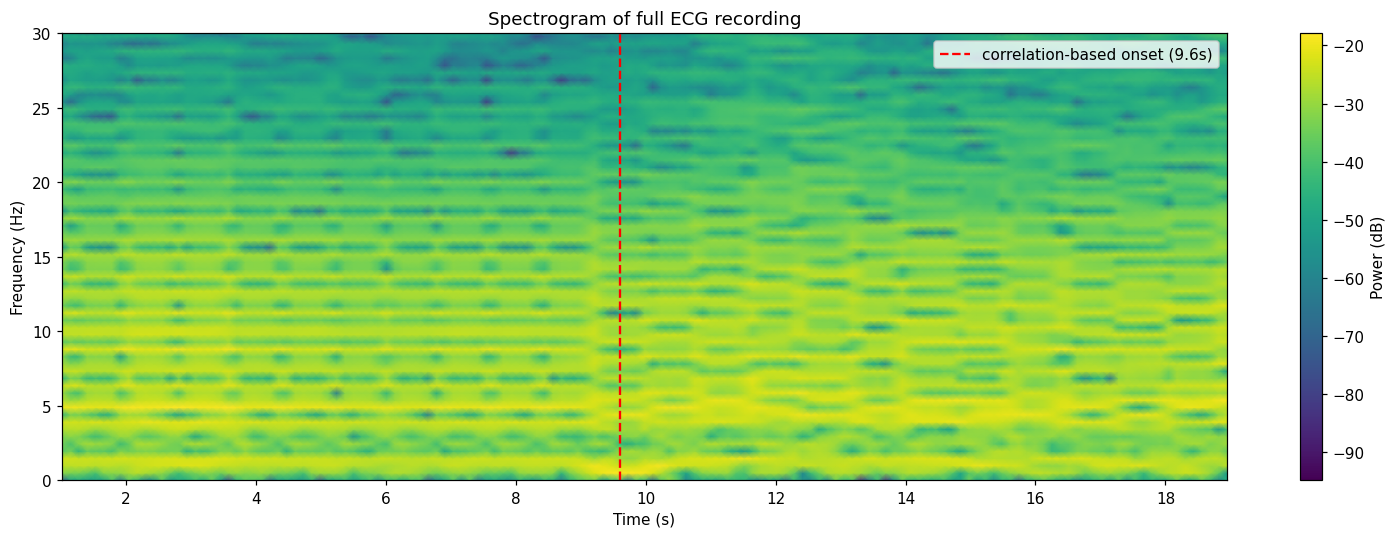

In [ ]:
f_spec, t_spec, Sxx = signal.spectrogram(ecg, fs=fs, nperseg=512, noverlap=480)  # compute spectrogram
plt.figure(figsize=(14,5))
plt.pcolormesh(t_spec, f_spec, 10*np.log10(Sxx + 1e-12), shading='gouraud', cmap='viridis')  # convert to dB and plot
plt.axvline(onset_time, color='red', linestyle='--', label=f'correlation-based onset ({onset_time:.1f}s)')  # mark where we detected the problem
plt.ylim(0, 30)  # focus on low frequencies
plt.ylabel('Frequency (Hz)'); plt.xlabel('Time (s)')
plt.title('Spectrogram of full ECG recording')
plt.legend(); plt.colorbar(label='Power (dB)')
plt.tight_layout(); plt.show()

The spectrogram confirms the qualitative prediction: clean, steady horizontal bands
(harmonics of $f_0=1.25$ Hz) are visible to the left of the red line (healthy region), which
become noticeably less regular and more smeared to the right of it (arrhythmia region) —
consistent with, though slightly less sharply localized in time than, the correlation-based
onset estimate.


## (f) Sampling & Aliasing

**(i) Minimum rate for content up to 40 Hz.** By the Nyquist–Shannon theorem, the sampling
rate must exceed twice the highest frequency present:
$$f_s^{\min} = 2 \times 40\ \text{Hz} = 80\ \text{Hz}$$

**(ii) What aliasing does to the QRS spikes at $f_s'=50$ Hz, and why it's dangerous.** Sampling
at 50 Hz is below the required 80 Hz, so frequency content above the new Nyquist frequency
($f_s'/2 = 25$ Hz) — which includes a large part of the QRS complex's sharp high-frequency
content — gets **aliased**: it folds back and masquerades as *lower*-frequency content,
corrupting the recorded waveform. In plain terms, the sharp, narrow QRS spike (which needs
high-frequency components to look sharp, per part (b)(ii)) would no longer be reconstructed
faithfully — it would appear smeared, distorted in shape, or even shifted in apparent timing/
amplitude. This is dangerous for Maya's detector because her whole method depends on
template-matching the *exact shape* of the QRS complex; aliasing distorts precisely that
shape, which could make genuinely healthy beats look abnormal (false alarms) or, worse, mask a
genuinely abnormal beat's distinguishing shape (missed detection).

**(iii) The fix and its unavoidable cost.** If the sampling rate really must be lowered, an
**anti-aliasing low-pass filter** must be applied before sampling, cutting off all content
above the new Nyquist frequency (here, above 25 Hz) so nothing above that can fold back and
corrupt the baseband. The unavoidable cost: this filter also removes genuine high-frequency
content of the real QRS complex (which the problem states extends up to ~40 Hz) — so the
recorded QRS spikes become permanently blunted/smoothed, losing some of their sharp clinical
detail, in exchange for avoiding the much worse corruption of aliasing.


In [ ]:
print('Required minimum sampling rate (Nyquist):', 2*40, 'Hz')  # need at least twice the max frequency
print('Proposed reduced rate:', 50, 'Hz  -> below the 80 Hz requirement, so aliasing WILL occur')  # this won't work
print('New Nyquist frequency at 50 Hz sampling:', 50/2, 'Hz')  # only half the bandwidth

Required minimum sampling rate (Nyquist): 80 Hz
Proposed reduced rate: 50 Hz  -> below the 80 Hz requirement, so aliasing WILL occur
New Nyquist frequency at 50 Hz sampling: 25.0 Hz


## (g) Prototyping the Detector in Code

(Implementation matching the exact specification: jump forward by the template length each
time — not sample-by-sample — and return the index of the first beat whose correlation drops
strictly below the threshold, or $-1$ if never breached.)


In [ ]:
def find_onset(ecg_signal, template, threshold):
    """
    Slide `template` across `ecg_signal` one full template-length at a time (beat-by-beat),
    compute the normalized correlation rho at each position, and return the index of the
    first beat where rho drops strictly below `threshold`. Returns -1 if never breached.
    """
    L = len(template)  # beat length
    N = len(ecg_signal)  # total signal length
    t_norm = np.linalg.norm(template)  # precompute template norm

    m = 0  # start at beginning
    while m + L <= N:  # make sure we don't run off the end
        segment = ecg_signal[m:m+L]  # extract current beat window
        seg_norm = np.linalg.norm(segment)  # get its magnitude
        rho = np.dot(template, segment) / (t_norm * seg_norm) if seg_norm > 0 else 0.0  # compute correlation
        if rho < threshold:  # first time we drop below threshold?
            return m  # return this index
        m += L  # move to next beat
    return -1  # never found one below threshold

# --- Demonstration on the real provided data ---
onset_index = find_onset(ecg, template, threshold=0.5)  # run the detector
print('First onset index:', onset_index, ' -> time:', onset_index/fs, 's')  # show the result

First onset index: 2400  -> time: 9.6 s


## (h) Visualizing the Spectrogram

**Window length choice: `nperseg = 512` samples** ($\approx 2.05$ s, spanning roughly 2.5
healthy beat periods).

*Reasoning:* the harmonics of the healthy ECG are spaced $f_0 = 1.25$ Hz apart (part (b)), so
to clearly resolve **separate, steady horizontal bands** rather than one blurred low-frequency
smear, the spectrogram's frequency resolution $\Delta f = f_s/\text{nperseg}$ must be
comfortably finer than 1.25 Hz; `nperseg=512` gives $\Delta f = 250/512 \approx 0.49$ Hz,
fine enough to separate adjacent harmonics, while still being short enough (about 2 seconds)
to localize the healthy-vs-arrhythmia transition reasonably well in time.


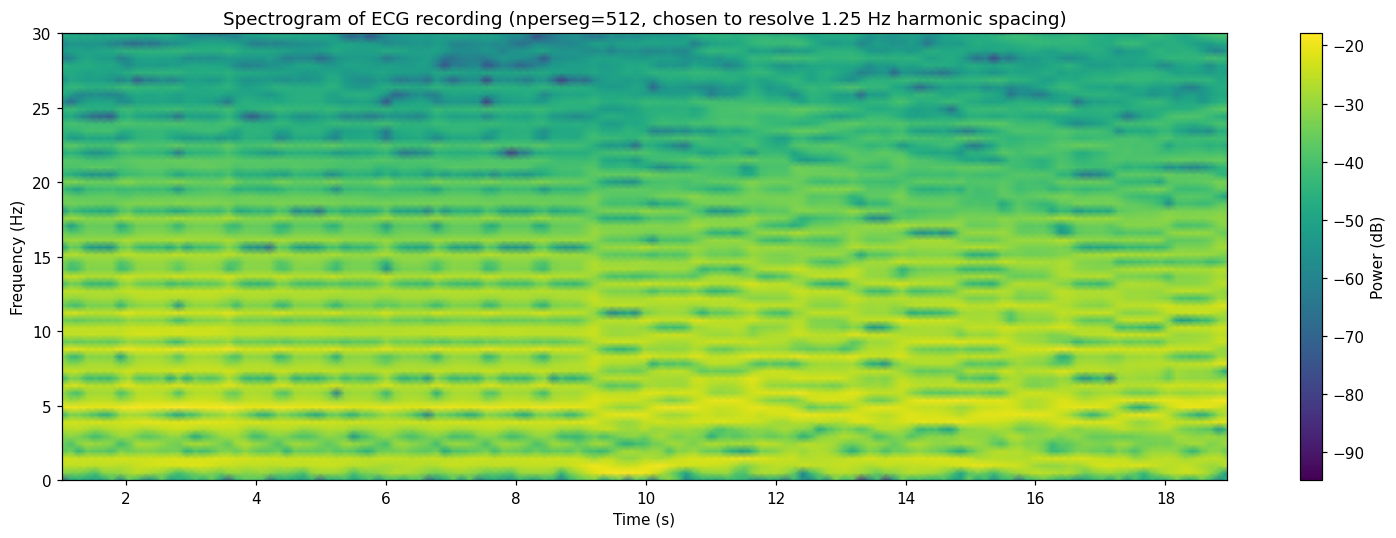

In [ ]:
f_spec, t_spec, Sxx = signal.spectrogram(ecg_signal := ecg, fs=fs, nperseg=512, noverlap=480)  # compute the spectrogram with chosen parameters

plt.figure(figsize=(14,5))
plt.pcolormesh(t_spec, f_spec, 10*np.log10(Sxx + 1e-12), shading='gouraud', cmap='viridis')  # plot in dB scale
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title('Spectrogram of ECG recording (nperseg=512, chosen to resolve 1.25 Hz harmonic spacing)')  # explaining the choice
plt.ylim(0, 30)  # only interested in low frequency range
plt.colorbar(label='Power (dB)')
plt.tight_layout(); plt.show()

**`nperseg = 512`** was chosen because it gives a frequency resolution
($\approx 0.49$ Hz) fine enough to clearly separate the 1.25 Hz-spaced harmonic lines of the
healthy rhythm into distinct steady horizontal bands, while remaining short enough in time
(~2 s) to still usefully localize where those bands degrade once the arrhythmia begins.
